In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.style.use('sci.mplstyle')

In [2]:
def luu_file(filename, u, err, L, k):
    n = u.shape[0]

    with open(filename, "w", encoding="utf-8") as file:
        file.write(f"### Ket qua tai vong lap {k}\n")
        file.write(f"### Max error = {np.max(err):.6e}\n")
        file.write("#" * 80 + "\n")
        file.write(f"### {'x':>15s} {'y':>15s} {'V':>15s} {'Error':>15s}\n")

        for i in range(n):
            for j in range(n):
                x = i * L / (n - 1)
                y = j * L / (n - 1)
                file.write(f"    {x:15.6f} {y:15.6f} {u[i,j]:15.6f} {err[i,j]:15.6e}\n")
            file.write("\n")

def doc_file_ketqua(filename):
    x, y, V, err = np.loadtxt(filename, unpack=True, comments="#")

    # Lay so diem luoi that su tu file
    x_unique = np.unique(x)
    y_unique = np.unique(y)

    nx = len(x_unique)
    ny = len(y_unique)

    print("File:", filename)
    print("nx =", nx)
    print("ny =", ny)
    print("So diem trong file =", len(x))
    print("nx * ny =", nx * ny)

    if nx * ny != len(x):
        raise ValueError("File khong phai luoi chu nhat day du")

    # Neu file luu theo for i rồi for j
    X = x.reshape(nx, ny)
    Y = y.reshape(nx, ny)
    V2D = V.reshape(nx, ny)
    err2D = err.reshape(nx, ny)

    return x_unique, y_unique, X, Y, V2D, err2D

In [3]:
# u        : mang nghiem kich thuoc n x n, da gan san dieu kien bien
# L        : chieu dai mien tinh toan, vi du mien [0, L] x [0, L]
# N_max    : so lan lap toi da neu chua hoi tu
# err_max  : nguong sai so hoi tu, dung khi max|u_moi - u_cu| < err_max
# filename : ten file output dung de luu nghiem va sai so

def hamtinh_laplace_gauss_seidel(u, mask_fixed, L, N_max=100000, err_max=1e-6, filename="bai2"):
    global h, rho, x, y
    n = u.shape[0]  # kich thuoc luoi n x n

    for k in range(N_max):
        u_old = u.copy()  # luu nghiem cua vong lap truoc

        # cap nhat cac diem ben trong theo cong thuc Gauss-Seidel
        for i in range(1, n - 1):
            for j in range(1, n - 1):
                if mask_fixed[i, j] == True:
                    continue
                u[i, j] = 0.25 * (
                    u[i + 1, j]  # diem ben phai
                    + u[i - 1, j]  # diem ben trai
                    + u[i, j + 1]  # diem ben tren
                    + u[i, j - 1]  # diem ben duoi
                    #+ h**2 * np.pi * rho(x[i], y[j]) 

                )
        # khi dang tinh u[i,j] thi u[i+1, j] va u[i, j + 1] la chua cap nhat nen no la old
        # trong khi do u[i-1, j] va u[i, j - 1] la chap nhat roi nen no la new

        # tinh sai so giua hai lan lap lien tiep
        err = np.abs(u - u_old)

        # lay sai so lon nhat tren toan bo luoi
        max_err = np.max(err)

        # kiem tra dieu kien hoi tu
        if max_err < err_max:
            print(f"Gauss-Seidel hoi tu sau {k} vong lap, max_err = {max_err:.3e}")

            # luu nghiem va sai so ra file
            luu_file(filename + "_gs_result.txt", u, err, L, k)

            return u

    # truong hop khong hoi tu sau N_max vong lap
    print(f"Gauss-Seidel khong hoi tu sau {N_max} vong lap, max_err = {max_err:.3e}")
    # luu ket qua cuoi cung ra file
    luu_file(filename + "_gs_result_khonghoitu.txt", u, err, L, N_max)

    return u

In [8]:
# u        : mang nghiem kich thuoc n x n, da gan san dieu kien bien
# L        : chieu dai mien tinh toan, vi du mien [0, L] x [0, L]
# N_max    : so lan lap toi da neu chua hoi tu
# err_max  : nguong sai so hoi tu, dung khi max|u_moi - u_cu| < err_max
# filename : ten file output dung de luu nghiem va sai so

def hamtinh_laplace_jacobi(u, mask_fixed, L, N_max=100000, err_max=1e-6, filename="bai1"):
    n = u.shape[0]  # kich thuoc luoi n x n
    # global h, rho, x, y # dung khi can su dung dang co dien tich

    # lap toi da N_max lan
    for k in range(N_max):
        u_old = u.copy()  # luu nghiem cua vong lap truoc

        u_new = u.copy()  # tao mang nghiem moi

        # cap nhat cac diem ben trong mien bang phuong phap Jacobi
        # tat ca gia tri moi deu duoc tinh tu u_old
        #u_new[1:-1, 1:-1] = 0.25 * (
        #      u_old[2:, 1:-1]      # diem ben phai
        #    + u_old[:-2, 1:-1]   # diem ben trai
        #    + u_old[1:-1, 2:]    # diem ben tren
        #    + u_old[1:-1, :-2]   # diem ben duoi
        #)

        for i in range(1, n - 1):
            for j in range(1, n - 1):
                if mask_fixed[i, j] == True:
                    continue
                u_new[i, j] = 0.25 * (u_old[i + 1, j] + u_old[i - 1, j] + u_old[i, j + 1]+ u_old[i, j - 1]) #+ h**2 * np.pi * rho(x[i], y[j])

        ## QUANTRONG: DUNG KHI LA PHUONG TRINH POISSON + h**2 * np.pi * rho(x[i], y[j])

        u = u_new  # cap nhat nghiem moi

        # tinh sai so giua hai lan lap lien tiep
        err = np.abs(u - u_old)

        # lay sai so lon nhat tren toan bo luoi
        max_err = np.max(err)

        # kiem tra dieu kien hoi tu
        if max_err < err_max:
            print(f"Jacobi hoi tu sau {k} vong lap, max_err = {max_err:.3e}")
            luu_file(filename + "_jacobi_result.txt", u, err, L, k)
            return u

    # truong hop khong hoi tu sau N_max vong lap
    print(f"Jacobi khong hoi tu sau {N_max} vong lap, max_err = {max_err:.3e}")

    
    luu_file(filename + "_jacobi_result_khonghoitu.txt", u, err, L, N_max)
    return u

# Tao hinh hop vuong ben trong

In [4]:
def dieukienbien_bai2(n, L, u_bien, u_hinhvuong, kichthuoc_hinhvuong):

    # Tao mang dien the ban dau
    u = np.zeros((n, n), dtype=float)

    # mask_fixed dung de danh dau diem khong duoc update
    # True  : bien ngoai hoac vat dan
    # False : diem nam trong mien can giai
    mask_fixed = np.zeros((n, n), dtype=bool)

    u[:, 0]  = u_bien      # bottom, y = 0
    u[:, -1] = u_bien      # top,    y = L
    u[0, :]  = u_bien      # left,   x = 0
    u[-1, :] = u_bien      # right,  x = L

    # Danh dau bien ngoai la diem co dinh
    mask_fixed[:, 0]  = True
    mask_fixed[:, -1] = True
    mask_fixed[0, :]  = True
    mask_fixed[-1, :] = True


    x = np.linspace(0, L, n)
    y = np.linspace(0, L, n)

    # Tam cua mien tinh toan
    x_center = L / 2
    y_center = L / 2

    # Canh cua hinh vuong vat dan
    a = kichthuoc_hinhvuong

    for i in range(n):
        for j in range(n):

            # Toa do  cua diem u[i, j]
            x_i = x[i]
            y_j = y[j]

            # Diem nam trong hinh vuong neu no cach tam
            # khong qua a/2 theo ca phuong x va phuong y
            if abs(x_i - x_center) <= a / 2 and abs(y_j - y_center) <= a / 2:
                u[i, j] = u_hinhvuong
                mask_fixed[i, j] = True

    return u, mask_fixed

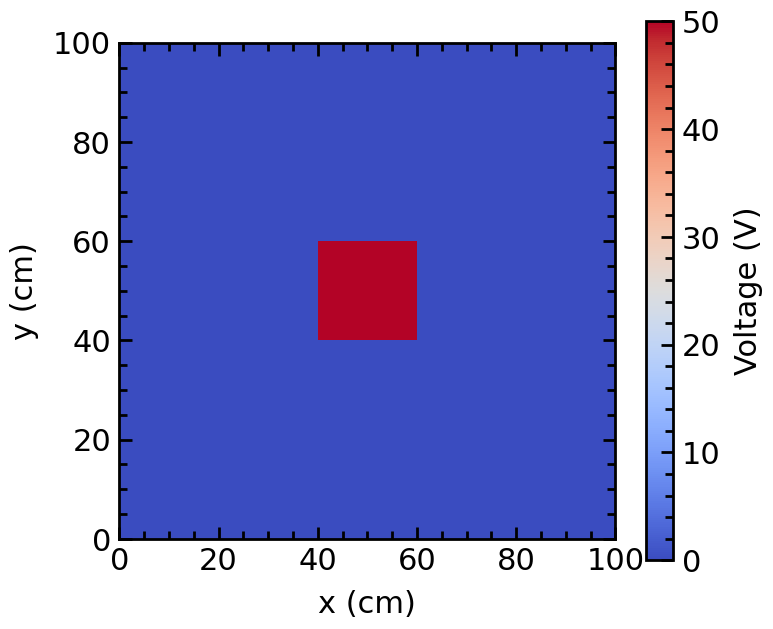

In [5]:
L = 100
n = 100
u_bien = 0
u_hinhvuong = 50
kichthuoc_hinhvuong = 0.2 * L

u_bien_bai2, mask_fixed_bai2 = dieukienbien_bai2(
    n,
    L,
    u_bien,
    u_hinhvuong,
    kichthuoc_hinhvuong
)

plt.figure(figsize=(8, 7))
plt.imshow(u_bien_bai2.T, origin='lower', cmap='coolwarm',extent=[0, 100, 0, 100], )
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.colorbar(label='Voltage (V)')
plt.show()
N_max = 100000
err_max = 1e-6

In [30]:
u_gs_bai2 = hamtinh_laplace_gauss_seidel(u_bien_bai2, mask_fixed_bai2, L, N_max=100000, err_max=1e-6, filename="bai2_gpt")

Gauss-Seidel hoi tu sau 0 vong lap, max_err = 9.966e-07


In [6]:
x_unique_bai2_gauss, y_unique_bai2_gauss, X_bai2_gauss, Y_bai2_gauss, V2D_bai2_gauss, err2D_bai2_gauss = doc_file_ketqua("bai2_gpt_gs_result.txt")

File: bai2_gpt_gs_result.txt
nx = 100
ny = 100
So diem trong file = 10000
nx * ny = 10000


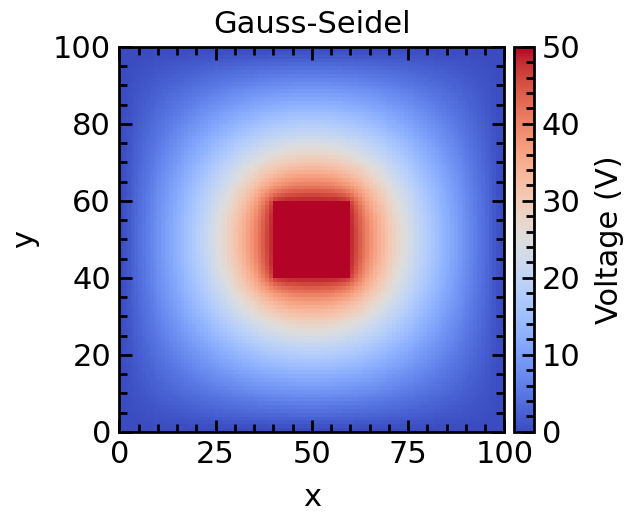

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(
    V2D_bai2_gauss.T,
    origin="lower",
    extent=[
        x_unique_bai2_gauss.min(), x_unique_bai2_gauss.max(),
        y_unique_bai2_gauss.min(), y_unique_bai2_gauss.max()
    ],
    cmap="coolwarm",
    aspect="equal",
    vmin=0,
    vmax=50
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Gauss-Seidel")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Voltage (V)")
#cbar.set_ticks([0, 20, 40, 60, 80, 100])

plt.savefig("bai2_gpt_gs.png", dpi = 300)

plt.show()

In [ ]:
u_gs_bai2 = hamtinh_laplace_jacobi(u_bien_bai2, mask_fixed_bai2, L, N_max=100000, err_max=1e-6, filename="bai2_gpt")

Jacobi hoi tu sau 7969 vong lap, max_err = 9.991e-07


In [10]:
x_unique_bai2_jacobi, y_unique_bai2_jacobi, X_bai2_jacobi, Y_bai2_jacobi, V2D_bai2_jacobi, err2D_bai2_jacobi = doc_file_ketqua("bai2_gpt_jacobi_result.txt")

File: bai2_gpt_jacobi_result.txt
nx = 100
ny = 100
So diem trong file = 10000
nx * ny = 10000


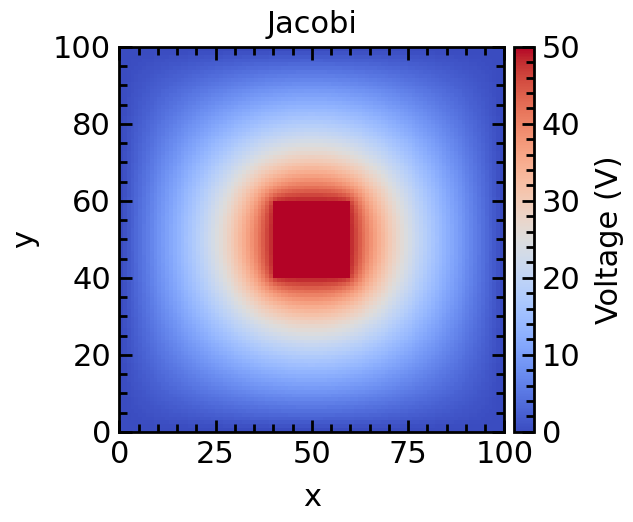

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(
    V2D_bai2_gauss.T,
    origin="lower",
    extent=[
        x_unique_bai2_gauss.min(), x_unique_bai2_gauss.max(),
        y_unique_bai2_gauss.min(), y_unique_bai2_gauss.max()
    ],
    cmap="coolwarm",
    aspect="equal",
    vmin=0,
    vmax=50
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Jacobi")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Voltage (V)")
#cbar.set_ticks([0, 20, 40, 60, 80, 100])

plt.savefig("bai2_gpt_jacobi.png", dpi = 300)

plt.show()